# Quantum_FL_RS_general_Ne_Nx

Clean generalized notebook for comparing the many-body Qiskit evolution with the Raffelt--Sigl mean-field evolution for

\[
N_e\;\nu_e + N_x\;\nu_x(\alpha),
\qquad
\nu_x(\alpha)=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu .
\]

This is the generalized version of the older fixed \(1\nu_e+15\nu_x\) notebook.

Default choice:

\[
N_e=1,\qquad N_x=15.
\]

To check \(N_e=2\) later, change only `Ne` in Cell 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

In [2]:
import argparse

parser = argparse.ArgumentParser(
    description="Many-body vs Random-Phase neutrino oscillation simulation"
)

parser.add_argument(
    "--Ne",
    type=int,
    help="Number of initially electron-flavor neutrinos",
)

parser.add_argument(
    "--Nx",
    type=int,
    help="Number of initially x-flavor neutrinos",
)

args, _ = parser.parse_known_args()

if args.Ne is None:
    Ne = int(input("Enter the number of electron-flavor neutrinos (Ne): "))
else:
    Ne = args.Ne

if args.Nx is None:
    Nx = int(input("Enter the number of x-flavor neutrinos (Nx): "))
else:
    Nx = args.Nx

N = Ne + Nx

if Ne < 1 or Nx < 1:
    raise ValueError("Ne and Nx must be positive integers.")

Enter the number of electron-flavor neutrinos (Ne):  1
Enter the number of x-flavor neutrinos (Nx):  10


In [3]:
# =============================
# CELL 1: Imports and parameters
# =============================

# -----------------------------
# Particle numbers
# -----------------------------


# -----------------------------
# Physics parameters
# -----------------------------
E = 1.0
dm2 = 1.0
theta_vac = 0.195

sin_2th = np.sin(2.0 * theta_vac)
cos_2th = np.cos(2.0 * theta_vac)
omega1 = dm2 / (4.0 * E)

bx = omega1 * np.sin(2.0 * theta_vac)
by = 0.0
bz = -omega1 * np.cos(2.0 * theta_vac)

# This is the scale used for the dimensionless time axis t*mu.
mu = 1

# -----------------------------
# Evolution choices
# -----------------------------
# Keep these False to match the later cells of the old e1_x15 notebook:
# self-interaction only, with no vacuum and no matter term.
use_vacuum = False
use_matter = False

# -----------------------------
# Time / Trotter / sampling parameters
# -----------------------------
dt = 0.01
T_max = 6 #200.0
sample_every = 25

n_steps_max = int(round(T_max / dt))
times = np.arange(0, n_steps_max + 1, sample_every) *dt

# -----------------------------
# Qiskit simulation parameters
# -----------------------------
shots = 4096
seed_simulator = 12345
backend = AerSimulator(seed_simulator=seed_simulator)

# -----------------------------
# Alpha cases
# -----------------------------
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
    (0.0,     r"0"),
]

print(f"Using Ne = {Ne}, Nx = {Nx}, total N = {N}")
print(f"omega1 = {omega1}")
print(f"mu = omega1 * N = {mu}")
print(f"Number of sampled times = {len(times)}, T_max = {T_max}, dt = {dt}")
print(f"Evolution mode: self-interaction only = {not use_vacuum and not use_matter}")

Using Ne = 1, Nx = 10, total N = 11
omega1 = 0.25
mu = omega1 * N = 1
Number of sampled times = 25, T_max = 6, dt = 0.01
Evolution mode: self-interaction only = True


In [4]:
# =======================================
# CELL 2: Interaction matrix J_ij
# =======================================



#J = interaction_matrix(N, dm2, E)
J=1
#print("J shape =", J.shape)
#print("J min/max =", J.min(), J.max())

In [5]:
# =========================================
# CELL 3: Qiskit evolution building blocks
# =========================================

def add_vacuum_evolution(qc, n, bx, by, bz, N):
    """
    Add n first-order vacuum steps to the circuit.

    This function is retained for completeness, but use_vacuum=False by default
    to match the old e1_x15 comparison.
    """
    for _ in range(n):
        for q in range(N):
            qc.rx(2.0 * bx, q)
            qc.ry(2.0 * by, q)
            qc.rz(2.0 * bz, q)


def add_interaction_evolution(qc, n, J, N, dt):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply approximately

        exp[-i Jij dt (XX + YY + ZZ)]

    using

        RXX(2 Jij dt) RYY(2 Jij dt) RZZ(2 Jij dt).
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 2.0 * J* dt
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

In [6]:
# ============================================
# CELL 4: Raffelt--Sigl mean-field solver
#        nu_e - antinu_x
# ============================================

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]], dtype=complex)
sigma_1 = np.array([[0, 1],  [1,  0]], dtype=complex)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_3 = np.array([[1, 0],  [0, -1]], dtype=complex)


def P_osc_RS(
    t_table,
    theta,
    omega,
    lam,
    J,
    initial_flavors=None,
    alpha=None
):
    """
    Raffelt--Sigl two-flavor polarization-vector evolution.

    Supports the effective-spin representation for both
    neutrino-neutrino and neutrino-antineutrino systems.

    Parameters
    ----------
    t_table : array
        Sampled times.

    theta : float
        Vacuum mixing angle.

    omega : array
        Vacuum frequencies for all modes.

    lam : float
        Matter strength.

    J : array
        Coupling matrix.

    initial_flavors : array
        Entries may be:

            'e'    : |nu_e>
            'x'    : |nu_mu>
            'mu'   : |nu_mu>
            'a'    : cos(alpha)|nu_e>
                     + sin(alpha)|nu_mu>

            'abar' : cos(alpha)|bar{nu}_e>
                     - sin(alpha)|bar{nu}_mu>

        For the effective antineutrino mapping,

            |bar{nu}_e> <-> |1/2,-1/2>
            |bar{nu}_mu> <-> -|1/2,+1/2>

        the effective polarization vector of |abar> is

            P_abar =
                (sin(2 alpha), 0, -cos(2 alpha)).

    alpha : float
        Superposition angle for modes labeled 'a' or 'abar'.
    """

    n_modes = omega.size

    # ============================================================
    # Vacuum Hamiltonian
    # ============================================================

    u = np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta), np.cos(theta)]
    ])

    b = 0.5 * np.diag([-1, 1])
    b = u @ b @ u.T

    # ============================================================
    # Matter Hamiltonian
    # ============================================================

    l = np.diag([1, 0])

    # ============================================================
    # Flavor polarization vectors
    # ============================================================

    Ee = np.array([0.0, 0.0,  1.0])
    Emu = np.array([0.0, 0.0, -1.0])

    # ============================================================
    # Hamiltonian polarization vectors
    # ============================================================

    B = np.real(np.array([
        np.trace(b @ sigma_1),
        np.trace(b @ sigma_2),
        np.trace(b @ sigma_3)
    ]))

    L = np.real(np.array([
        np.trace(l @ sigma_1),
        np.trace(l @ sigma_2),
        np.trace(l @ sigma_3)
    ]))

    # ============================================================
    # Default initial state
    # ============================================================

    ini_state = np.where(
        omega > 0,
        Ee[:, None],
        Emu[:, None]
    )

    # ============================================================
    # Explicit initial states
    # ============================================================

    if initial_flavors is not None:

        initial_flavors = np.asarray(initial_flavors)

        # --------------------------------------------------------
        # Check labels
        # --------------------------------------------------------

        valid_labels = [
            "e",
            "x",
            "mu",
            "a",
            "abar"
        ]

        for f in initial_flavors:

            if f not in valid_labels:
                raise ValueError(
                    f"Unknown flavor label: {f}"
                )

            if f in ["a", "abar"] and alpha is None:
                raise ValueError(
                    f"Flavor label '{f}' requires alpha."
                )

        # --------------------------------------------------------
        # Ordinary neutrino states
        # --------------------------------------------------------

        ini_state[
            :,
            initial_flavors == "e"
        ] = Ee[:, None]

        ini_state[
            :,
            initial_flavors == "x"
        ] = Emu[:, None]

        ini_state[
            :,
            initial_flavors == "mu"
        ] = Emu[:, None]

        # --------------------------------------------------------
        # |a> = cos(alpha)|nu_e>
        #       + sin(alpha)|nu_mu>
        #
        # P_a = (sin 2alpha, 0, cos 2alpha)
        # --------------------------------------------------------

        ini_state[
            :,
            initial_flavors == "a"
        ] = np.array([
            np.sin(2.0 * alpha),
            0.0,
            np.cos(2.0 * alpha)
        ])[:, None]

        # --------------------------------------------------------
        # Antineutrino state
        #
        # |bar{x}> =
        #     cos(alpha)|bar{nu}_e>
        #     - sin(alpha)|bar{nu}_mu>
        #
        # With
        #
        # |bar{nu}_e> <-> |down>
        # |bar{nu}_mu> <-> -|up>
        #
        # we obtain
        #
        # |bar{x}>
        #     <-> cos(alpha)|down>
        #         + sin(alpha)|up>
        #
        # Therefore
        #
        # P_abar =
        #     (sin 2alpha, 0, -cos 2alpha)
        # --------------------------------------------------------

        ini_state[
            :,
            initial_flavors == "abar"
        ] = np.array([
            np.sin(2.0 * alpha),
            0.0,
            -np.cos(2.0 * alpha)
        ])[:, None]

    # ============================================================
    # Raffelt--Sigl equations of motion
    # ============================================================

    def rhs(t, P_flat):

        """
        dP_k/dt = H_k x P_k

        H_k =
            omega_k B
            + lambda L
            + sum_j J_kj P_j

        In the effective-spin representation the
        neutrino-antineutrino interaction is represented
        by the same collective Hamiltonian.
        """

        res = np.zeros(3 * n_modes)

        PP = np.reshape(
            P_flat,
            (n_modes, 3)
        ).T

        for k in range(n_modes):

            H_k = (
                omega[k] * B
                + lam * L
                + 1 * J * np.sum(PP, axis=1)
            )

            res[
                3*k:3*k+3
            ] = np.cross(
                H_k,
                PP[:, k]
            )

        return res

    # ============================================================
    # Integrate
    # ============================================================

    return integ.solve_ivp(
        rhs,
        (t_table[0], t_table[-1]),
        ini_state.T.flatten(),
        t_eval=t_table,
    )

In [7]:
# =====================================================
# CELL 5: Many-body Qiskit solver for Ne + Nx(alpha)
# =====================================================

def prepare_initial_circuit(Ne, Nx, alpha):
    """
    Prepare the initial many-body state:

        first Ne qubits: |nu_e> = |0>
        next  Nx qubits: |nu_x(alpha)> = cos(alpha)|0> + sin(alpha)|1>

    RY(2 alpha)|0> = cos(alpha)|0> + sin(alpha)|1>.

    For alpha = pi/2, the Nx group is exactly |1>, reproducing
    the old 1 nu_e + 15 nu_mu setup when Ne=1, Nx=15.
    """
    N = Ne + Nx
    qc0 = QuantumCircuit(N, N)

    # First Ne qubits are |nu_e> = |0>, so no gate is needed.
    for q in range(Ne, N):
        qc0.ry(2.0 * alpha, q)

    return qc0


def run_many_body_qiskit(alpha, Ne, Nx, J, times, dt, shots, backend,
                         use_vacuum=False, bx=0.0, by=0.0, bz=0.0,
                         verbose=True):
    """
    Run the many-body Qiskit simulation for a given alpha.

    Output
    ------
    P_bit1[q, k] :
        Probability that qubit q is measured as |1> at time times[k].

    For the first Ne qubits, which start as |nu_e>=|0>,
        P_bit1 = P(nu_e -> nu_mu).

    The plotted observable is the Ne-average:
        <P(nu_e -> nu_mu)> over the initially electron-flavor group.
    """
    N = Ne + Nx
    qc0 = prepare_initial_circuit(Ne, Nx, alpha)

    P_bit1 = [[] for _ in range(N)]

    for t in times:
        n = int(round(t / dt))
        qc = qc0.copy()

        #if use_vacuum:
            #add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

        add_interaction_evolution(qc, n=n, J=J, N=N, dt=dt)

        qc.measure(range(N), range(N))

        tqc = transpile(qc, backend, optimization_level=0)
        counts = backend.run(tqc, shots=shots).result().get_counts()

        p1_t = [0.0] * N

        for bitstring, c in counts.items():
            prob = c / shots

            for q in range(N):
                # Qiskit displays bitstrings with the highest classical bit first.
                bit_q = int(bitstring[-1 - q])
                if bit_q == 1:
                    p1_t[q] += prob

        for q in range(N):
            P_bit1[q].append(p1_t[q])

        if verbose:
            print(
                f"alpha={alpha:.6f}, t={t:8.3f}: "
                f"<P_e_to_mu>_MB = {np.mean(p1_t[:Ne]):.5f}"
            )

    P_bit1 = np.array(P_bit1)

    return {
        "P_bit1": P_bit1,
        "P_e_to_mu_avg": np.mean(P_bit1[:Ne, :], axis=0),
    }

In [8]:
# =====================================================
# CELL 6: RS solver and combined alpha-case runner
#        nu_e - antinu_x
# =====================================================

def run_rs_mean_field(alpha, Ne, Nx, J, times,
                      use_vacuum=False, use_matter=False):
    """
    Run the Raffelt--Sigl mean-field evolution for

        nu_e ... nu_e  x  bar{x} ... bar{x}

    with Ne neutrinos in beam 1 and Nx antineutrinos
    in beam 2.

    The antineutrino state is

        |bar{x}> =
            cos(alpha)|bar{nu}_e>
            - sin(alpha)|bar{nu}_mu>,

    represented in the effective spin basis by

        P_bar{x} =
            (sin(2 alpha), 0, -cos(2 alpha)).

    Default:
        omega = 0,
        lambda = 0,

    so this solves the self-interaction-only mean-field problem.
    """

    N = Ne + Nx

    # ============================================================
    # Vacuum term
    # ============================================================

    if use_vacuum:
        omega = np.ones(N) * omega1
        theta_rs = theta_vac
    else:
        omega = np.zeros(N)
        theta_rs = 0.0

    # ============================================================
    # Matter term
    # ============================================================

    lam = 1.0 if use_matter else 0.0

    # ============================================================
    # Initial state
    #
    # First beam:
    #     nu_e ... nu_e
    #
    # Second beam:
    #     bar{x} ... bar{x}
    # ============================================================

    initial_flavors = np.array(
        ["e"] * Ne + ["abar"] * Nx
    )

    # ============================================================
    # Run Raffelt--Sigl solver
    # ============================================================

    sol = P_osc_RS(
        times,
        theta_rs,
        omega,
        lam,
        J,
        initial_flavors=initial_flavors,
        alpha=alpha,
    )

    # ============================================================
    # Reshape solution
    # ============================================================

    P_all = sol.y

    P = P_all.reshape(
        N,
        3,
        -1
    )

    Pz = P[:, 2, :]

    # ============================================================
    # Conversion probability
    #
    # Beam 1 contains ordinary neutrinos, therefore
    #
    # P(nu_e -> nu_mu) = (1 - Pz)/2.
    #
    # We only average over the first Ne modes.
    # ============================================================

    P_mu = 0.5 * (1.0 - Pz)

    P_e_to_mu_avg = np.mean(
        P_mu[:Ne, :],
        axis=0
    )

    return {
        "sol": sol,
        "P": P,
        "Pz": Pz,
        "P_mu": P_mu,
        "P_e_to_mu_avg": P_e_to_mu_avg,
    }


def run_alpha_case(alpha, verbose=True):
    """
    Run both many-body Qiskit and RS mean-field calculations
    for the nu_e - antinu_x initial state.
    """

    N = Ne + Nx
    J = 1

    # ============================================================
    # Many-body calculation
    # ============================================================

    mb = run_many_body_qiskit(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        dt=dt,
        shots=shots,
        backend=backend,
        use_vacuum=use_vacuum,
        bx=bx,
        by=by,
        bz=bz,
        verbose=verbose,
    )

    # ============================================================
    # Raffelt--Sigl mean-field calculation
    # ============================================================

    rs = run_rs_mean_field(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        use_vacuum=use_vacuum,
        use_matter=use_matter,
    )

    # ============================================================
    # Return both results
    # ============================================================

    return {
        "alpha": alpha,
        "Ne": Ne,
        "Nx": Nx,
        "many_body": mb,
        "rs": rs,
    }

In [9]:
# =====================================================
# CELL 7: Plotting helpers
# =====================================================

results = {}

# Choose the x-axis used in all plots.
# Options:
#     "t"    : physical notebook time
#     "t_mu" : dimensionless t*mu
plot_time_axis = "t"


def get_plot_time():
    if plot_time_axis == "t":
        return times, r"Total time"
    elif plot_time_axis == "t_mu":
        return times , r"$t\mu$"
    else:
        raise ValueError("plot_time_axis must be either 't' or 't_mu'.")


def run_and_plot_alpha(alpha, alpha_label, fig_no=None, verbose=True, show_plot=True):
    """
    Run one alpha case and optionally plot the average conversion probability
    of the initially electron-flavor group.
    """
    key = alpha_label
    result = run_alpha_case(alpha, verbose=verbose)
    results[key] = result

    if show_plot:
        P_mb = result["many_body"]["P_e_to_mu_avg"]
        P_rs = result["rs"]["P_e_to_mu_avg"]

        x, xlabel = get_plot_time()

        plt.figure(figsize=(9, 5.5))

        plt.plot(
            x,
            P_mb,
            marker="o",
            linestyle="dashed",
            label=rf"Many-body Qiskit, $\alpha={alpha_label}$",
        )

        plt.plot(
            x,
            P_rs,
            linestyle="-",
            linewidth=2,
            label=rf"RS mean field, $\alpha={alpha_label}$",
        )

        plt.xlabel(xlabel)
        plt.ylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")

        if fig_no is None:
            plt.title(
                rf"$N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )
        else:
            plt.title(
                rf"Fig. {fig_no}: $N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

In [10]:
# =====================================================
# IBM circuit construction
# =====================================================

def build_ibm_circuit(alpha, Ne, Nx, J, t, dt):
    """
    Build the same many-body circuit used by the Qiskit simulation,
    but without measurements.

    EstimatorV2 evaluates expectation values directly.
    """
    N = Ne + Nx

    qc = prepare_initial_circuit(Ne, Nx, alpha)

    n = int(round(t / dt))

    if use_vacuum:
        add_vacuum_evolution(
            qc,
            n=n,
            bx=bx,
            by=by,
            bz=bz,
            N=N,
        )

    add_interaction_evolution(
        qc,
        n=n,
        J=J,
        N=N,
        dt=dt,
    )

    return qc

## Figures for different \(\alpha\)

Each cell below runs one \(\alpha\) case and produces one figure.

The plotted observable is the average conversion probability of the initially electron-flavor group:

\[
\left\langle P(\nu_e\rightarrow \nu_\mu)\right\rangle_{N_e}.
\]

In [11]:
import numpy as np
from scipy.special import gammaln
from sympy.physics.wigner import clebsch_gordan
from sympy import S as sympy_S


def cg_coefficient(j1, m1, j2, m2, J, M):
    """
    Clebsch-Gordan coefficient

        <j1,m1; j2,m2 | J,M>

    using the SymPy convention.
    """
    return float(
        clebsch_gordan(
            sympy_S(j1),
            sympy_S(j2),
            sympy_S(J),
            sympy_S(m1),
            sympy_S(m2),
            sympy_S(M)
        )
    )


def collective_nunubar_conversion_probability(
    N1,
    N2,
    alpha,
    t,
    lam=1.0,
    sector_cutoff=1e-12
):
    """
    Collective nu_e -> nu_mu conversion probability for
    neutrino-antineutrino interactions.

    The initial state is

        |nu_e ... nu_e>_N1
        x
        |bar{x} ... bar{x}>_N2

    with

        |bar{x}> =
            cos(alpha) |bar{nu}_e>
            - sin(alpha) |bar{nu}_mu>,

    represented in the effective spin basis according to

        |bar{nu}_e> <-> |1/2,-1/2>
        |bar{nu}_mu> <-> -|1/2,+1/2>.

    The second beam is decomposed as

        |bar{x}...bar{x}>
        =
        sum_m bar{c}_m |N2/2,m>,

    where

        bar{c}_m =
        sqrt(C(N2, N2/2-m))
        (cos alpha)^(N2/2-m)
        (-sin alpha)^(N2/2+m).

    Parameters
    ----------
    N1 : int
        Number of nu_e neutrinos in beam 1.

    N2 : int
        Number of antineutrinos in beam 2.

    alpha : float
        Mixing angle.

    t : float or array-like
        Evolution time.

    lam : float, optional
        Interaction strength lambda.

    sector_cutoff : float, optional
        Discard sectors whose binomial probability is below
        this value.

    Returns
    -------
    P_emu : float or ndarray
        Probability that one neutrino in beam 1 converts
        from nu_e to nu_mu.
    """

    # ============================================================
    # Input checks
    # ============================================================

    if not isinstance(N1, (int, np.integer)):
        raise TypeError("N1 must be an integer.")

    if not isinstance(N2, (int, np.integer)):
        raise TypeError("N2 must be an integer.")

    if N1 < 1 or N2 < 1:
        raise ValueError("N1 and N2 must be positive integers.")

    # ============================================================
    # Spin quantum numbers
    # ============================================================

    j1 = N1 / 2
    j2 = N2 / 2

    Jmax = j1 + j2

    # ============================================================
    # Time array
    # ============================================================

    t = np.asarray(t, dtype=float)

    Nmu = np.zeros_like(t, dtype=float)

    # ============================================================
    # Mixing parameters
    # ============================================================

    c = np.cos(alpha)
    s = np.sin(alpha)

    p_c = c**2
    p_s = s**2

    p_c = np.clip(p_c, 0.0, 1.0)
    p_s = np.clip(p_s, 0.0, 1.0)

    # ============================================================
    # Sum over i
    #
    # m = N2/2 - i
    #
    # bar{c}_m^2 =
    #
    # C(N2,i)
    # (cos^2 alpha)^i
    # (sin^2 alpha)^(N2-i)
    #
    # i=0 corresponds to m=N2/2, i.e. the pure
    # bar{nu}_mu sector. This sector cannot convert
    # nu_e -> nu_mu and is therefore omitted.
    # ============================================================

    for i in range(1, N2 + 1):

        # --------------------------------------------------------
        # Sector weight
        # --------------------------------------------------------

        if p_c == 0.0:

            # alpha = pi/2
            #
            # Only i = 0 has nonzero weight, which is the
            # pure bar{nu}_mu sector and does not convert.
            continue

        elif p_s == 0.0:

            # alpha = 0
            #
            # Only i = N2 survives.
            if i != N2:
                continue

            weight = 1.0

        else:

            log_weight = (
                gammaln(N2 + 1)
                - gammaln(i + 1)
                - gammaln(N2 - i + 1)
                + i * np.log(p_c)
                + (N2 - i) * np.log(p_s)
            )

            weight = np.exp(log_weight)

        # --------------------------------------------------------
        # Negligible sector
        # --------------------------------------------------------

        if weight < sector_cutoff:
            continue

        # ========================================================
        # Conserved total magnetic quantum number
        #
        # M = N1/2 + m
        #   = (N1+N2)/2 - i
        # ========================================================

        M = Jmax - i

        # ========================================================
        # Allowed total-spin values
        # ========================================================

        Smin = max(
            abs(j1 - j2),
            abs(M)
        )

        S_values = np.arange(
            Smin,
            Jmax + 1,
            1
        )

        # ========================================================
        # Number of nu_e -> nu_mu conversions
        #
        # Initial:
        #
        #   m1 = N1/2
        #   m2 = N2/2 - i
        #
        # After j conversions:
        #
        #   m1 = N1/2 - j
        #   m2 = N2/2 - i + j
        #
        # ========================================================

        for j in range(1, min(i, N1) + 1):

            # ----------------------------------------------------
            # Initial product-state quantum numbers
            # ----------------------------------------------------

            m1_initial = j1
            m2_initial = j2 - i

            # ----------------------------------------------------
            # Final product-state quantum numbers
            # ----------------------------------------------------

            m1_final = j1 - j
            m2_final = j2 - i + j

            # ----------------------------------------------------
            # Transition amplitude
            #
            # A_j(t) =
            #
            # sum_S
            # C_initial C_final
            # exp[-i E_S t]
            # ----------------------------------------------------

            real_part = np.zeros_like(
                t,
                dtype=float
            )

            imag_part = np.zeros_like(
                t,
                dtype=float
            )

            for Stotal in S_values:

                # Initial CG coefficient

                C_initial = cg_coefficient(
                    j1,
                    m1_initial,
                    j2,
                    m2_initial,
                    Stotal,
                    M
                )

                # Final CG coefficient

                C_final = cg_coefficient(
                    j1,
                    m1_final,
                    j2,
                    m2_final,
                    Stotal,
                    M
                )

                coefficient = (
                    C_initial * C_final
                )

                # ------------------------------------------------
                # Energy eigenvalue
                #
                # E_S = lambda S(S+1)
                # ------------------------------------------------

                E_S = (
                    lam
                    * Stotal
                    * (Stotal + 1)
                )

                # exp(-i E_S t)

                real_part += (
                    coefficient
                    * np.cos(E_S * t)
                )

                imag_part -= (
                    coefficient
                    * np.sin(E_S * t)
                )

            # ----------------------------------------------------
            # Probability for exactly j conversions
            # ----------------------------------------------------

            P_j = (
                real_part**2
                + imag_part**2
            )

            # ----------------------------------------------------
            # Contribution to <N_mu>
            # ----------------------------------------------------

            Nmu += (
                weight
                * j
                * P_j
            )

    # ============================================================
    # Probability for one neutrino in beam 1
    # ============================================================

    return Nmu / N1

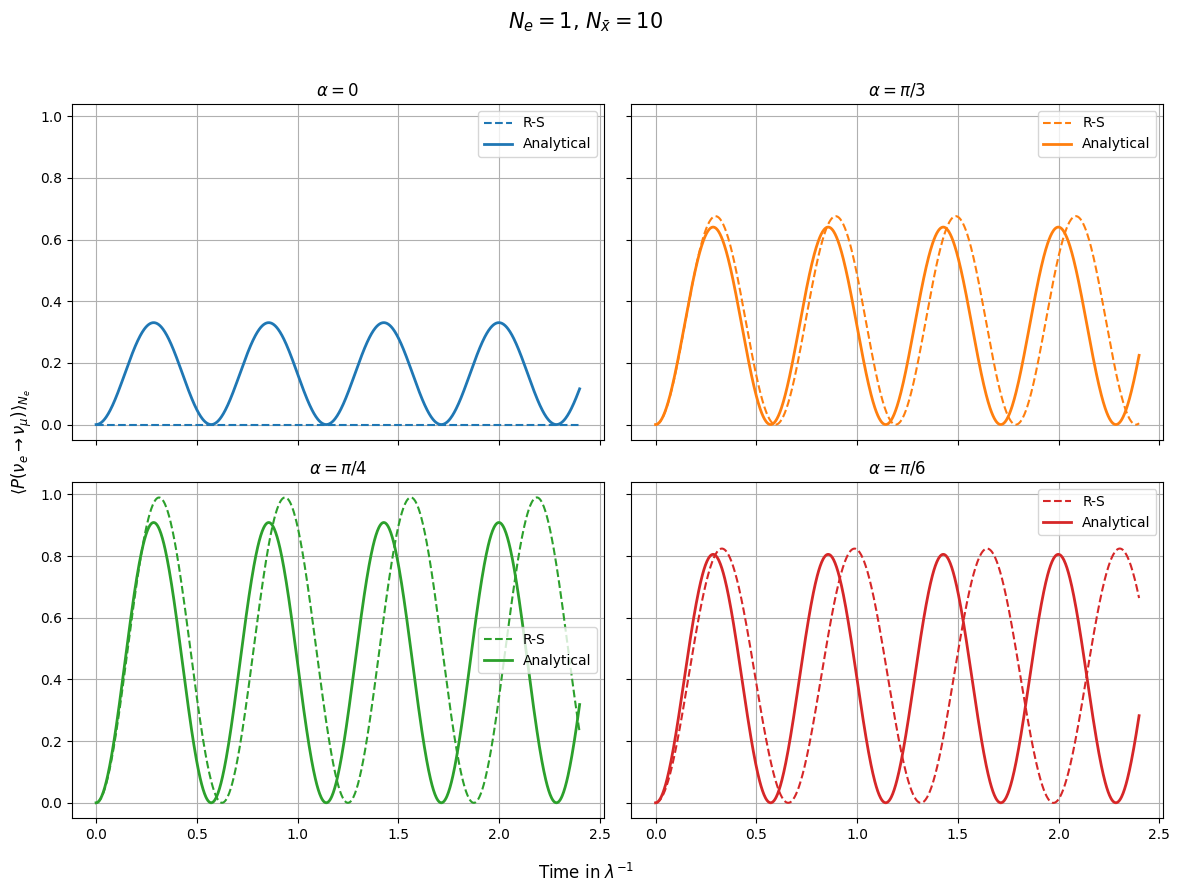

In [14]:
# =====================================================
# CELL 7: Compare RS mean field with analytical result
# for all alpha cases
# =====================================================

alpha_cases = [
    (0, r"0"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
]

P_rs = {}
P_emu = {}
t=np.linspace(0,2.4,1000)
t_an= np.linspace(0,2.4,1000)
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, (alpha, alpha_label), color in zip(
    axes, alpha_cases, colors
):

    # -------------------------------------------------
    # Raffelt-Sigl mean-field solution
    # -------------------------------------------------
    result_rs = run_rs_mean_field(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=t,
        use_vacuum=use_vacuum,
        use_matter=use_matter,
    )

    # Average P(nu_e -> nu_mu) over the initial nu_e modes
    P_rs[alpha_label] = result_rs["P_e_to_mu_avg"]

    # -------------------------------------------------
    # Analytical collective-oscillation result
    # -------------------------------------------------
    P = collective_nunubar_conversion_probability(
        N1=Ne,
        N2=Nx,
        alpha=alpha,
        t=t_an,
        lam=J
    )

    P_emu[alpha_label] = P

    # -------------------------------------------------
    # Plotting time variable
    # -------------------------------------------------
    x, xlabel = get_plot_time()

    ax.plot(
        t,
        P_rs[alpha_label],
        "--",
        color=color,
        label="R-S"
    )

    ax.plot(
        t_an,
        P_emu[alpha_label],
        "-",
        lw=2,
        color=color,
        label="Analytical"
    )

    ax.set_title(rf"$\alpha={alpha_label}$")
    ax.grid(True)
    ax.legend()


# -----------------------------------------------------
# Figure labels
# -----------------------------------------------------
fig.supxlabel(r"Time in $\lambda^{-1}$")
fig.supylabel(
    r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$"
)

fig.suptitle(
    rf"$N_e={Ne}$, $N_{{\bar{{x}}}}={Nx}$",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 